In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

esconv_train = pd.read_parquet("../data/processed/esconv/train.parquet")
esconv_val = pd.read_parquet("../data/processed/esconv/val.parquet")
esconv_test = pd.read_parquet("../data/processed/esconv/test.parquet")

emp_train = pd.read_parquet("../data/processed/empathetic/train.parquet")

esconv = pd.concat([esconv_train, esconv_val, esconv_test], ignore_index=True)

print(esconv.shape)
print(esconv.dtypes)
esconv.head()

(38365, 10)
conv_id               int64
turn_idx              int64
speaker              object
text                 object
strategy             object
emotion_type         object
problem_type         object
situation            object
initial_intensity    object
final_intensity      object
dtype: object


,conv_id,turn_idx,speaker,text,strategy,emotion_type,problem_type,situation,initial_intensity,final_intensity
0,0,0,usr,Hello good afternoon.,None,anxiety,job crisis,I am on short term disability and I am afraid ...,3,2
1,0,1,sys,"Hi, good afternoon.",Question,anxiety,job crisis,I am on short term disability and I am afraid ...,3,2
2,0,2,usr,I'm feeling anxious that I am going to lose my...,None,anxiety,job crisis,I am on short term disability and I am afraid ...,3,2
3,0,3,sys,Losing a job is always anxious.,Reflection of feelings,anxiety,job crisis,I am on short term disability and I am afraid ...,3,2
4,0,4,usr,I hope I don't.,None,anxiety,job crisis,I am on short term disability and I am afraid ...,3,2


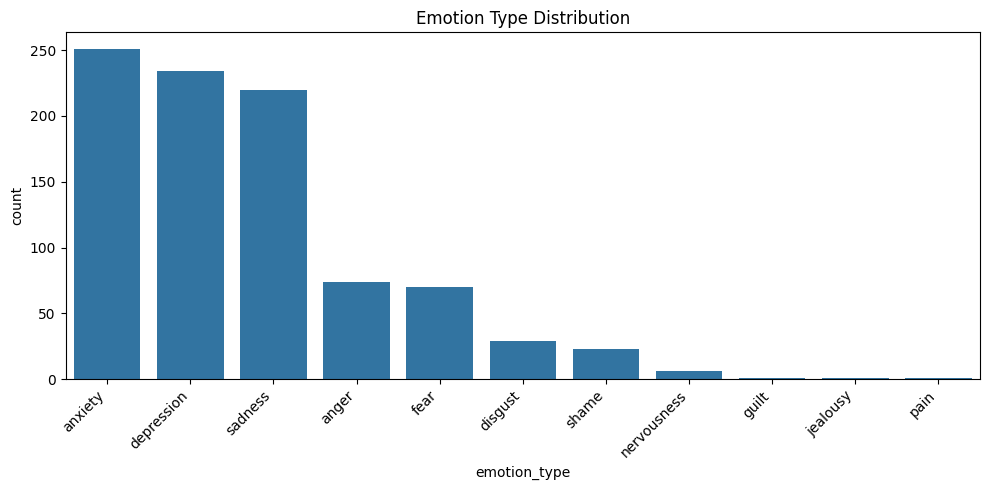

In [3]:
plt.figure(figsize=(10, 5))
sns.countplot(data=esconv.drop_duplicates('conv_id'), x='emotion_type', order=esconv.drop_duplicates('conv_id')['emotion_type'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title('Emotion Type Distribution')
plt.tight_layout()
plt.show()

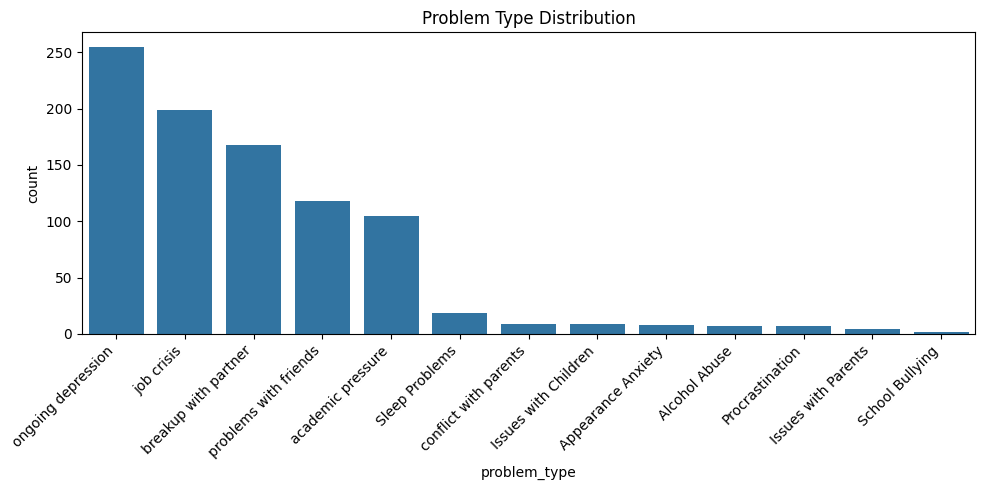

In [4]:
plt.figure(figsize=(10, 5))
sns.countplot(data=esconv.drop_duplicates('conv_id'), x='problem_type', order=esconv.drop_duplicates('conv_id')['problem_type'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title('Problem Type Distribution')
plt.tight_layout()
plt.show()

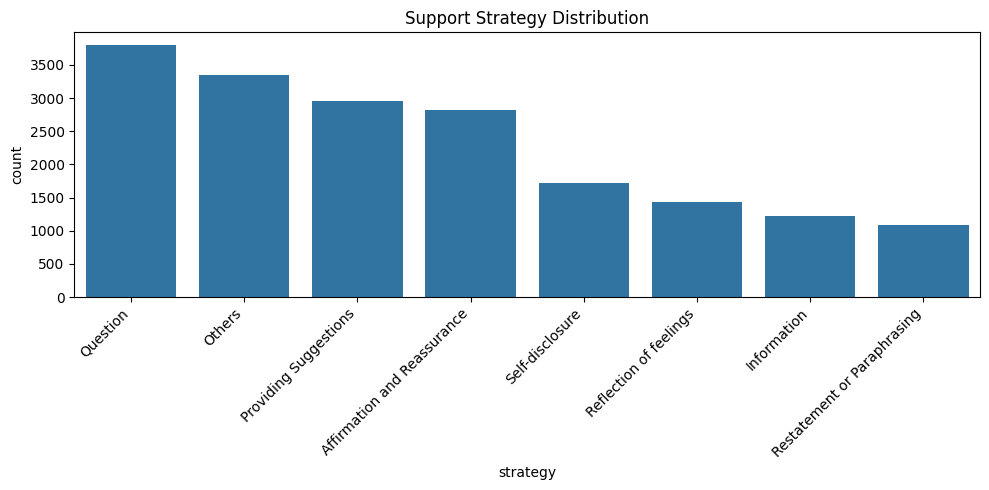

In [5]:
plt.figure(figsize=(10, 5))
sns.countplot(data=esconv[esconv['strategy'].notna()], x='strategy', order=esconv['strategy'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title('Support Strategy Distribution')
plt.tight_layout()
plt.show()

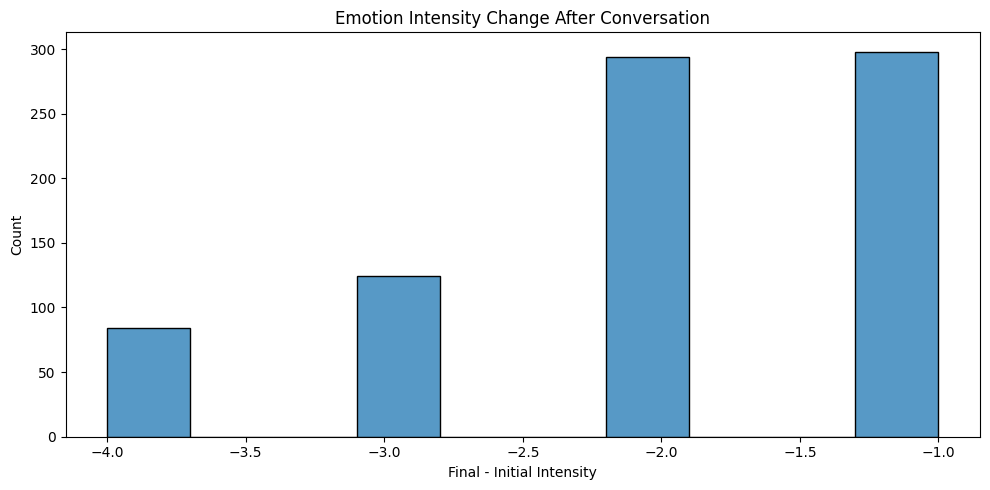

count    800.000000
mean      -1.992500
std        0.973976
min       -4.000000
25%       -3.000000
50%       -2.000000
75%       -1.000000
max       -1.000000
Name: intensity_change, dtype: float64


In [6]:
conv_level = esconv.drop_duplicates('conv_id').copy()
conv_level = conv_level.dropna(subset=['initial_intensity', 'final_intensity'])
conv_level['initial_intensity'] = conv_level['initial_intensity'].astype(int)
conv_level['final_intensity'] = conv_level['final_intensity'].astype(int)
conv_level['intensity_change'] = conv_level['final_intensity'] - conv_level['initial_intensity']

plt.figure(figsize=(10, 5))
sns.histplot(conv_level['intensity_change'], bins=10)
plt.title('Emotion Intensity Change After Conversation')
plt.xlabel('Final - Initial Intensity')
plt.tight_layout()
plt.show()

print(conv_level['intensity_change'].describe())

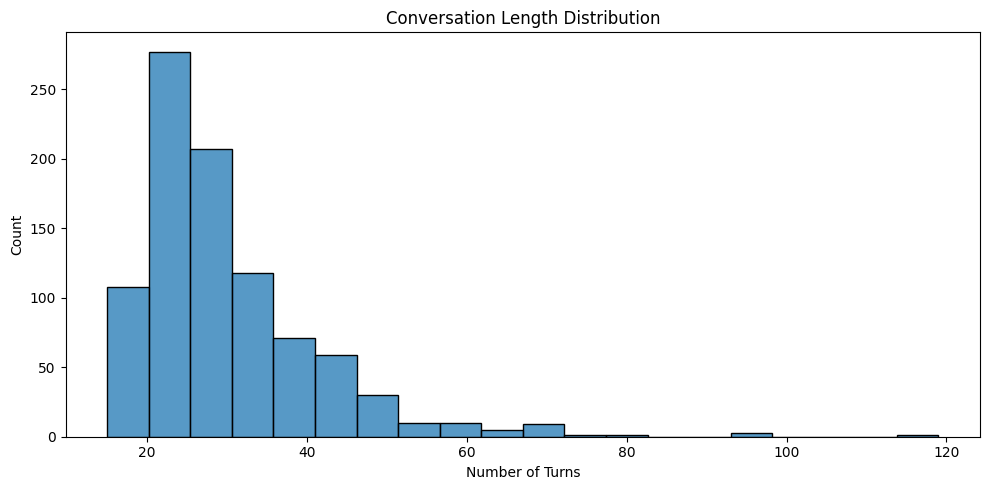

count    910.000000
mean      30.017582
std       11.287508
min       15.000000
25%       22.250000
50%       27.000000
75%       34.000000
max      119.000000
Name: num_turns, dtype: float64


In [7]:
conv_lengths = esconv.groupby('conv_id')['turn_idx'].max().reset_index()
conv_lengths.columns = ['conv_id', 'num_turns']

plt.figure(figsize=(10, 5))
sns.histplot(conv_lengths['num_turns'], bins=20)
plt.title('Conversation Length Distribution')
plt.xlabel('Number of Turns')
plt.tight_layout()
plt.show()

print(conv_lengths['num_turns'].describe())

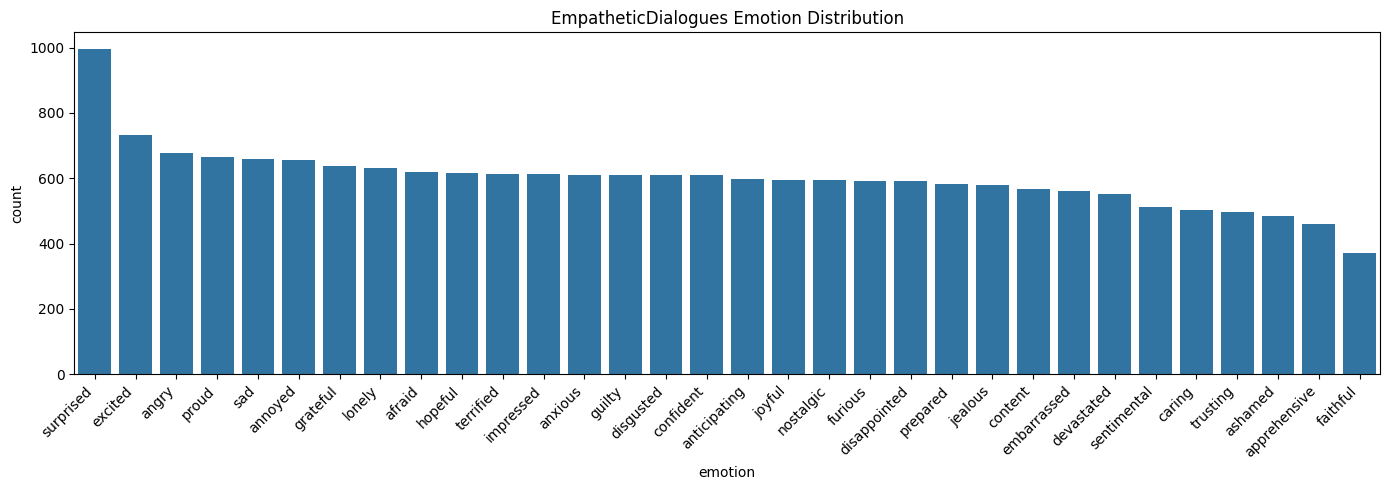

32 unique emotions
emotion
surprised    997
excited      731
angry        677
proud        666
sad          660
annoyed      657
grateful     637
lonely       633
afraid       619
hopeful      615
Name: count, dtype: int64


In [8]:
plt.figure(figsize=(14, 5))
sns.countplot(data=emp_train, x='emotion', order=emp_train['emotion'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title('EmpatheticDialogues Emotion Distribution')
plt.tight_layout()
plt.show()

print(emp_train['emotion'].nunique(), "unique emotions")
print(emp_train['emotion'].value_counts().head(10))